## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie

In [32]:
df = pd.read_csv('data/AirPassengers.csv', parse_dates = ['date'], index_col = 'date')
df

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


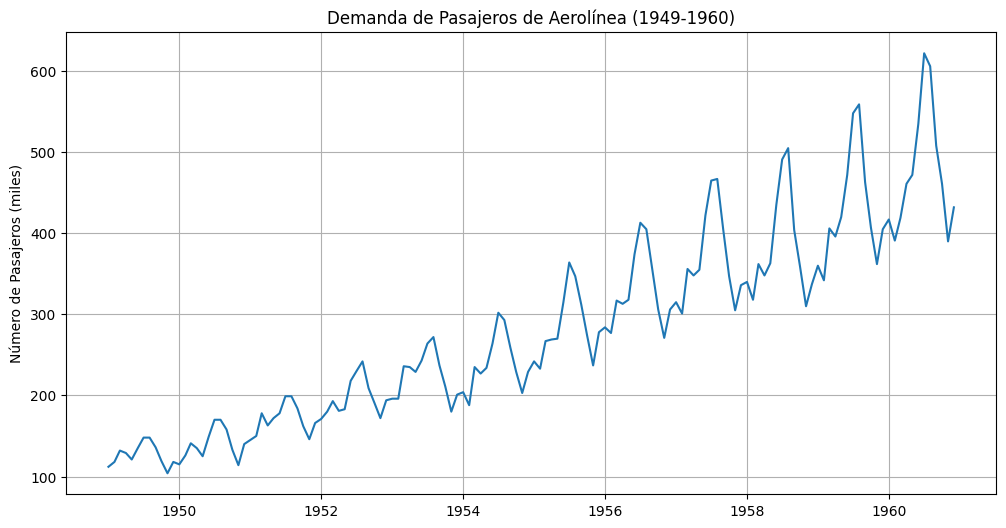

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df['value'], label='Pasajeros')
plt.title('Demanda de Pasajeros de Aerolínea (1949-1960)')
plt.ylabel('Número de Pasajeros (miles)')
plt.grid(True)

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior

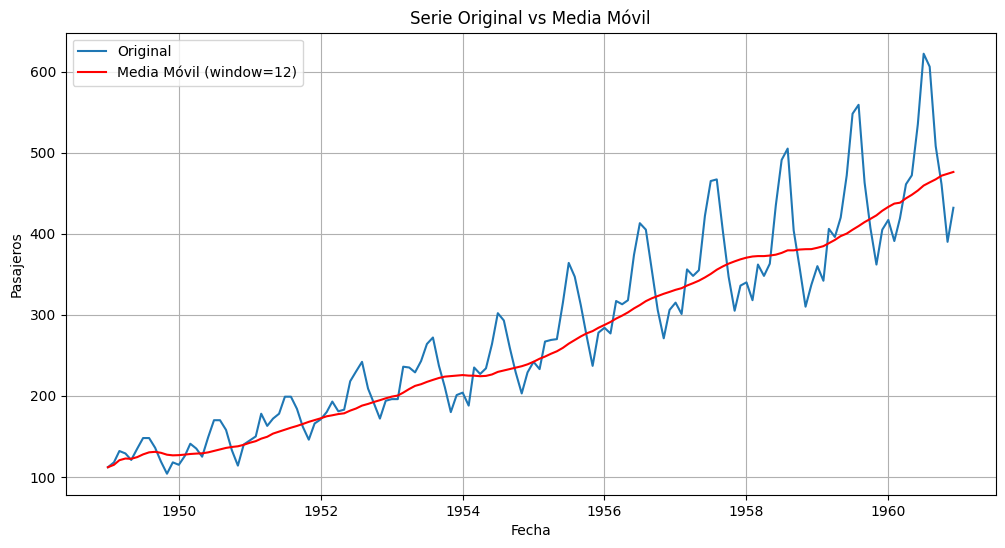

In [12]:
df['rolling_mean'] = df['value'].rolling(window=12, min_periods=1).mean()

# Gráfica
plt.figure(figsize=(12, 6))
plt.plot(df['value'], label='Original')
plt.plot(df['rolling_mean'], color='red', label=f'Media Móvil (window={12})')
plt.title('Serie Original vs Media Móvil')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [20]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['value'].values)
result[1]

np.float64(0.991880243437641)

## 4. Aplica una transformación logarítmica

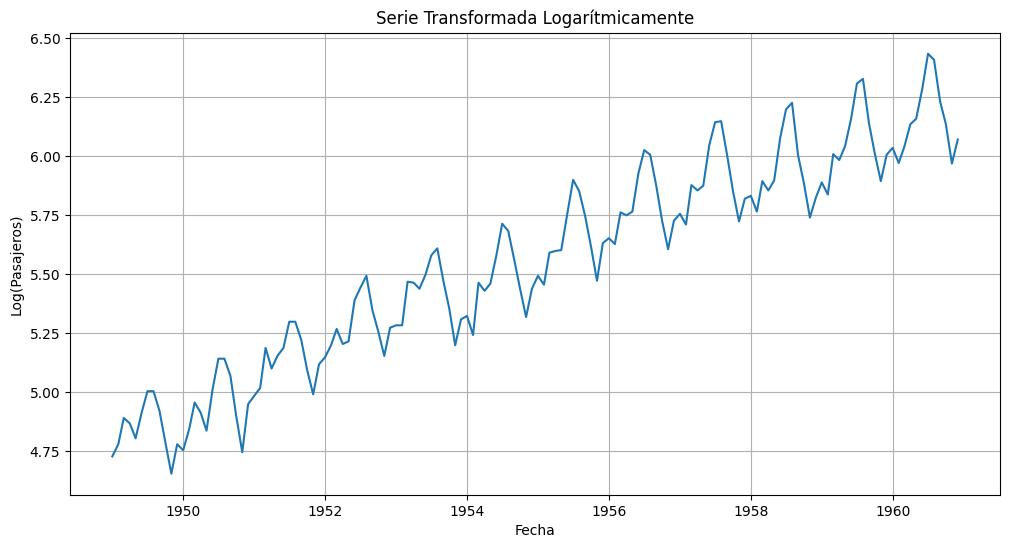

In [24]:
# Code# Aplicar logaritmo para estabilizar la varianza (la serie crece exponencialmente)
df['log_val'] = np.log1p(df['value'])

# Visualizar la transformación
plt.figure(figsize=(12, 6))
plt.plot(df['log_val'])
plt.title('Serie Transformada Logarítmicamente')
plt.xlabel('Fecha')
plt.ylabel('Log(Pasajeros)')
plt.grid(True)
plt.show()

## 5. Divide en train y test. Guarda 20 muestras para test.

In [37]:
train = df.iloc[:-20,:1]
test = df.iloc[-20:,:1]

## 6. Crea tu primer modelo ARIMA

In [39]:
from pmdarima.arima import auto_arima

# Ajuste automático del modelo SARIMA
smodel = auto_arima(
    train,                  # Serie temporal de entrada (array 1D, lista o pd.Series)
    
    # --- Determinación de la diferenciación (d) ---
    test='adf',            # Prueba estadística para determinar 'd' automáticamente. 
                           # 'adf' = Augmented Dickey-Fuller (prueba de raíz unitaria).
    d=None,                # Orden de diferenciación no estacional. 
                           # Al ser None, se calcula automáticamente usando la prueba 'test'.
    
    # --- Parámetros no estacionales (ARIMA: p, d, q) ---
    start_p=1,             # Valor inicial desde donde comienza la búsqueda del orden AR (p).
    start_q=1,             # Valor inicial desde donde comienza la búsqueda del orden MA (q).
    max_p=3,               # Límite máximo para el orden AR (p). No buscará valores > 3.
    max_q=3,               # Límite máximo para el orden MA (q). No buscará valores > 3.
    
    # --- Parámetros estacionales (SARIMA: P, D, Q, m) ---
    seasonal=True,         # Activa la componente estacional. Si False, ignora P, D, Q y m.
    m=12,                  # Periodo estacional. 12 suele indicar datos mensuales con ciclo anual.
    start_P=0,             # Valor inicial para la búsqueda del orden AR estacional (P).
    D=1,                   # Orden de diferenciación estacional. 
                           # ¡Ojo! Al poner un número fijo (1), NO se optimiza automáticamente.
                           # Si quisieras que se calcule solo, deberías poner D=None.
    
    # --- Control del algoritmo y salida ---
    trace=True,            # Imprime en consola el progreso de la búsqueda (modelos probados y AIC).
    error_action='ignore', # Si un modelo falla al ajustarse, lo ignora y sigue con el siguiente.
                           # Otras opciones: 'warn' (avisa), 'raise' (detiene el código).
    suppress_warnings=True,# Oculta advertencias técnicas de statsmodels (ej. no convergencia).
    stepwise=True          # Usa búsqueda paso a paso (más rápida) en lugar de exhaustiva (grid search).
                           # Recomienda modelos vecinos si mejoran el criterio de información.
)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=840.372, Time=0.35 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=840.999, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=838.710, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=839.471, Time=0.08 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=837.876, Time=0.02 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=838.989, Time=0.09 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.49 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=839.344, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=839.199, Time=0.05 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=838.427, Time=0.03 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=841.152, Time=0.06 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=839.642, Time=0.05 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 1.341 seconds


## 7. Representa en una gráfica los datos de test y tus predicciones.

In [46]:
start_index = len(train)
end_index = len(train) + len(test) - 1
predictions_log = smodel.predict(start=start_index, end=end_index, dynamic=False)
predictions = np.exp(predictions_log)

ValueError: x and y must have same first dimension, but have shapes (20,) and (10,)

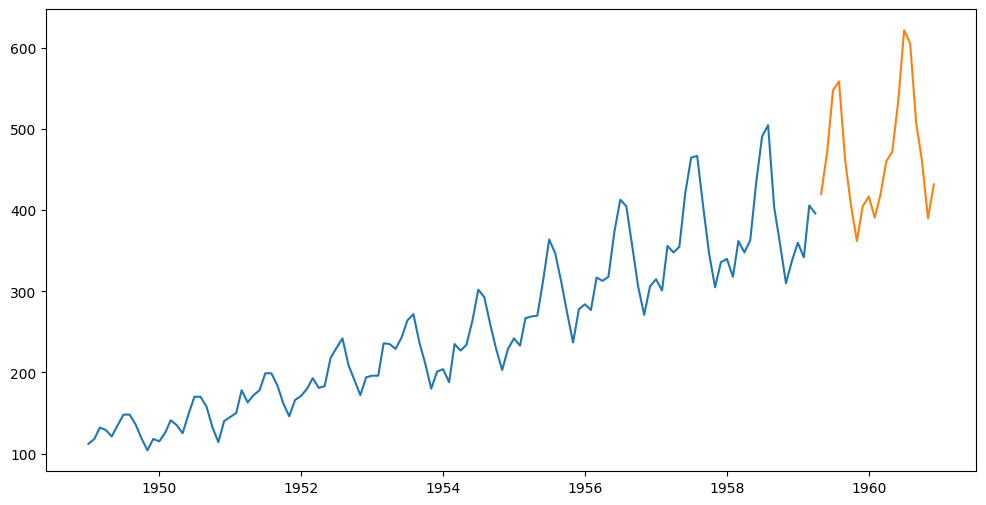

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['value'], label='Train')
plt.plot(test.index, test['value'], label='Test Real')
plt.plot(test.index, predictions, label='Predicción ARIMA', linestyle='--')
plt.title('Predicción ARIMA vs Datos Reales')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.show()

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [ ]:
# Code